# Exploratory Data Analysis

## Setup

### Libraries

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

from pyspark.sql import functions as F
from pyspark.sql import Window
from src.config import DATA_DIR
from src.data.aggregate import get_spark
from src.data.aggregate import load_raw
from src.features.build_features import trim_cold_start

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data

In [2]:
spark = get_spark()
weekly = spark.read.parquet(str(DATA_DIR / "weekly.parquet"))
print("rows:", weekly.count())   # 8_445_730

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/10 14:22:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


rows: 8445730


## EDA-1 -- Overview

In [3]:
# Number of series (item x store) — sanity check
n_series = weekly.select("id").distinct().count()
print("series:", n_series)   # attendu : 30490

# What proportion of (series, week) are at 0 sales ?
zero_share = weekly.filter(F.col("sales") == 0).count() / weekly.count()
print(f"Share of weeks with 0 sales : {zero_share:.1%}")

# Weekly sales distribution by quantile
weekly.select("sales").summary(
    "min", "25%", "50%", "75%", "90%", "99%", "max"
).show()

series: 30490
Share of weeks with 0 sales : 39.7%


+-------+-----+
|summary|sales|
+-------+-----+
|    min|    0|
|    25%|    0|
|    50%|    2|
|    75%|    7|
|    90%|   19|
|    99%|   94|
|    max| 3539|
+-------+-----+



## EDA-1 -- Volume & 0-sales week overview

- **30,490 series** (item × store), each spanning 277 full weeks after partial-week removal.
- **39.7% of (series, week) cells have zero sales** — weekly aggregation fills many
  daily zeros (a slow mover selling once a week is ~85% zeros daily but near-0%
  weekly). The weekly grain already dampens intermittency by design.
- This 39.7% still includes **cold-start zeros** (weeks before a product was
  introduced in a store), so true demand intermittency is lower still — to be
  isolated in EDA-2.
- **Weekly sales are right-skewed** but not pathological: median = 2, Q3 = 7,
  P90 = 19, P99 = 94, max = 3,539. Half of all weeks have ≥ 2 sales, so a
  meaningful share of series are dense enough for z-score-based signals.
- The gap between a zero Q1 and a non-zero median suggests zeros are
  **concentrated in a sub-population of sparse series** rather than spread
  uniformly — motivating the dense/intermittent segmentation (EDA-3) and
  predicting a bimodal density distribution.
- **Modeling implication:** a naive z-score can't be applied blindly across all
  series; injection-based evaluation will be restricted to the dense pool.

## EDA-2 -- Remove zero-sales week

In [5]:
trimmed = trim_cold_start(weekly)

print("rows before:", weekly.count())     # 8_445_730
print("rows after :", trimmed.count())    # < 8_445_730

# Le nouveau poids des zéros — la "vraie" intermittence de demande
zero_share_after = trimmed.filter(F.col("sales") == 0).count() / trimmed.count()
print(f"zero share after trim: {zero_share_after:.1%}")   # < 39.7%

rows before: 8445730


rows after : 6686246


zero share after trim: 23.9%


## EDA-2 -- Cold-start trimming

- Removed **1,759,484 leading zero weeks (21% of the raw grid)** — cells before
  each product's first real sale, i.e. "not yet stocked" rather than zero demand.
- Zero share drops from **39.7% → 23.9%** after trimming: ~16 points of the
  apparent intermittency was a product-lifecycle artifact, not demand sparsity.
- Series now have **variable life spans** (recently introduced products span
  fewer weeks); density will be computed over each series' effective life, not a
  uniform 277-week window.
- **True weekly demand intermittency is moderate (23.9%)**, consistent with the
  non-zero median — the dense pool for injection-based evaluation should be
  sizable.

## EDA-3 -- Series density and distribution

In [6]:
def compute_density(trimmed):
    """Density per series = share of active weeks with non-zero sales,
    over the series' effective life (post cold-start trim)."""
    density = (
        trimmed.groupBy("id", "item_id", "dept_id", "cat_id", "store_id", "state_id")
        .agg(
            F.count("*").alias("life_weeks"),
            F.sum(F.when(F.col("sales") > 0, 1).otherwise(0)).alias("active_weeks"),
        )
        .withColumn("density", F.col("active_weeks") / F.col("life_weeks"))
    )
    return density

In [7]:
# Computation using Spark then saved as pandas df
density = compute_density(trimmed)
density_pd = density.select(
    "id", "cat_id", "dept_id", "state_id", "life_weeks", "active_weeks", "density"
).toPandas()

print("séries:", len(density_pd))   # 30490
print(density_pd["density"].describe())

séries: 30490
count    30490.000000
mean         0.762053
std          0.195172
min          0.037736
25%          0.639344
50%          0.807692
75%          0.924188
max          1.000000
Name: density, dtype: float64


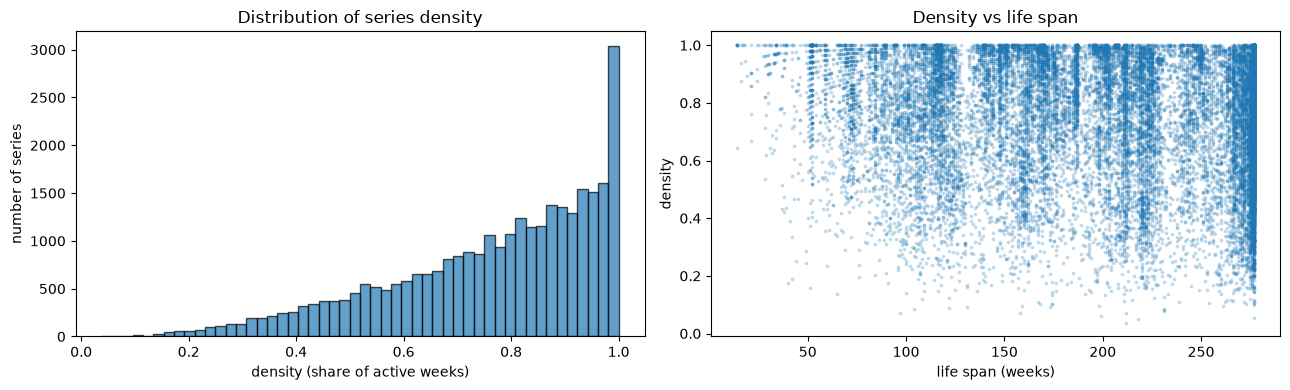

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme des densités — c'est ICI qu'on lit la bimodalité (ou non)
ax[0].hist(density_pd["density"], bins=50, edgecolor="black", alpha=0.7)
ax[0].set_xlabel("density (share of active weeks)")
ax[0].set_ylabel("number of series")
ax[0].set_title("Distribution of series density")

# Densité vs durée de vie — pour repérer un éventuel effet cycle de vie résiduel
ax[1].scatter(density_pd["life_weeks"], density_pd["density"], s=3, alpha=0.2)
ax[1].set_xlabel("life span (weeks)")
ax[1].set_ylabel("density")
ax[1].set_title("Density vs life span")

plt.tight_layout()
plt.show()

In [9]:
for thr in [0.6, 0.7, 0.8, 0.9]:
    n = (density_pd["density"] >= thr).sum()
    print(f"density >= {thr}: {n:5d} series ({n/len(density_pd):.1%})")

density >= 0.6: 24191 series (79.3%)
density >= 0.7: 20607 series (67.6%)
density >= 0.8: 15688 series (51.5%)
density >= 0.9:  9312 series (30.5%)


In [10]:
DENSITY_THR = 0.8
MIN_LIFE_WEEKS = 52

dense_mask = (density_pd["density"] >= DENSITY_THR) & (density_pd["life_weeks"] >= MIN_LIFE_WEEKS)
print(f"dense pool: {dense_mask.sum()} series ({dense_mask.mean():.1%})")

# Distribution by category to avoid bias towards one of them
print(density_pd[dense_mask]["cat_id"].value_counts())

dense pool: 15509 series (50.9%)
cat_id
FOODS        8235
HOUSEHOLD    5056
HOBBIES      2218
Name: count, dtype: int64


## EDA-3 -- Density distribution & dense-pool definition

- Density (share of active weeks over effective life) forms a **continuous,
  right-rising distribution — no bimodality, no natural gap.** Dense and sparse
  series lie on a continuum, not in two separable populations.
- Density is **uncorrelated with life span** (scatter), confirming cold-start
  trimming left no residual lifecycle effect.
- With no natural cut, the threshold is set by **evaluation need, not
  distribution shape**: a rolling z-score / reconstruction error requires a
  well-defined local variance, which degrades below ~0.8 density.
- **Dense pool = density ≥ 0.8 AND life span ≥ 52 weeks** (the 52-week floor
  guarantees the year-over-year seasonal-deviation feature is computable).
- Pool size is not a constraint: 51.5% of series pass density ≥ 0.8 alone;
  the combined criterion retains 15509 series across all three categories.

In [11]:
dense_ids = density_pd[dense_mask][["id"]]
dense_ids.to_parquet(DATA_DIR / "dense_series.parquet", index=False)
print("saved", len(dense_ids), "dense series ids")

saved 15509 dense series ids


## EDA-4 -- Seasonality

In [14]:
dense_ids = spark.read.parquet(str(DATA_DIR / "dense_series.parquet"))
dense = trimmed.join(dense_ids, on="id", how="inner")

# week of the year (YYWW) : last 2 digits
dense = dense.withColumn("woy", F.col("wm_yr_wk") % 100)

# overall seasonality profile : average sales by week of the year
seasonal_global = (
    dense.groupBy("woy")
    .agg(F.mean("sales").alias("mean_sales"))
    .orderBy("woy")
    .toPandas()
)

# seasonality profile by category
seasonal_cat = (
    dense.groupBy("woy", "cat_id")
    .agg(F.mean("sales").alias("mean_sales"))
    .orderBy("woy")
    .toPandas()
)

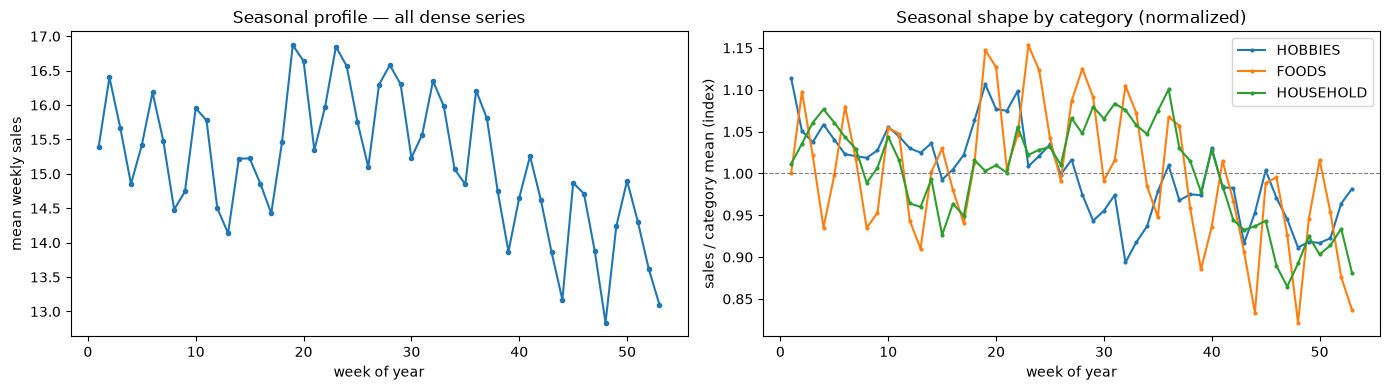

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Global
ax[0].plot(seasonal_global["woy"], seasonal_global["mean_sales"], marker="o", ms=3)
ax[0].set_xlabel("week of year")
ax[0].set_ylabel("mean weekly sales")
ax[0].set_title("Seasonal profile — all dense series")

# By category (normalised to compare the shapes, not the levels themselves)
for cat in seasonal_cat["cat_id"].unique():
    sub = seasonal_cat[seasonal_cat["cat_id"] == cat].copy()
    sub["norm"] = sub["mean_sales"] / sub["mean_sales"].mean()   # indice base 1
    ax[1].plot(sub["woy"], sub["norm"], marker="o", ms=2, label=cat)
ax[1].axhline(1.0, color="gray", ls="--", lw=0.8)
ax[1].set_xlabel("week of year")
ax[1].set_ylabel("sales / category mean (index)")
ax[1].set_title("Seasonal shape by category (normalized)")
ax[1].legend()

plt.tight_layout()
plt.show()

## EDA-4 (seasonality) -- apparent profile is a truncation artifact

- The global seasonal profile shows sales *declining* toward year-end — the
  opposite of expected US retail seasonality.
- **Cause: M5 ends 19 Jun 2016.** Weeks 1–16 are averaged over 6 years
  (2011–2016), weeks 17–52 over only 5 (2011–2015). Since 2016 is the
  highest-volume year (upward trend), early-year weeks are inflated and
  late-year weeks are not — mixing seasonality with trend and uneven year
  coverage. (Week 53 has a single year, hence noisy.)
- The regular high/low zigzag is a **monthly SNAP effect**, not noise — to be
  quantified in the events/SNAP volet.
- **Decision:** do not derive features from the global seasonal profile. Seasonal
  deviation is computed **per series, year-over-year (N-1)** — robust to the
  truncation artifact and to trend, since it compares each week to the same week
  of the same series one year earlier. (This is what the ≥52-week life-span floor
  on the dense pool guarantees.)

In [19]:
# count the nb of years by week number
dense.groupBy("woy").agg(
    F.countDistinct("year").alias("n_years")
).orderBy("woy").show(60)

+---+-------+
|woy|n_years|
+---+-------+
|  1|      6|
|  2|      6|
|  3|      6|
|  4|      6|
|  5|      6|
|  6|      6|
|  7|      6|
|  8|      6|
|  9|      6|
| 10|      6|
| 11|      6|
| 12|      6|
| 13|      6|
| 14|      6|
| 15|      6|
| 16|      6|
| 17|      5|
| 18|      5|
| 19|      5|
| 20|      5|
| 21|      5|
| 22|      5|
| 23|      5|
| 24|      5|
| 25|      5|
| 26|      5|
| 27|      5|
| 28|      5|
| 29|      5|
| 30|      5|
| 31|      5|
| 32|      5|
| 33|      5|
| 34|      5|
| 35|      5|
| 36|      5|
| 37|      5|
| 38|      5|
| 39|      5|
| 40|      5|
| 41|      5|
| 42|      5|
| 43|      5|
| 44|      5|
| 45|      5|
| 46|      5|
| 47|      5|
| 48|      5|
| 49|      5|
| 50|      5|
| 51|      5|
| 52|      5|
| 53|      1|
+---+-------+



In [20]:
# full years only (2011-2015) — troncated 2016 is excluded
dense_full = dense.filter(F.col("year") < 2016)

# clean global profile
seasonal_clean = (
    dense_full.groupBy("woy")
    .agg(F.mean("sales").alias("mean_sales"))
    .orderBy("woy")
    .toPandas()
)

# by category
seasonal_cat_clean = (
    dense_full.groupBy("woy", "cat_id")
    .agg(F.mean("sales").alias("mean_sales"))
    .orderBy("woy")
    .toPandas()
)

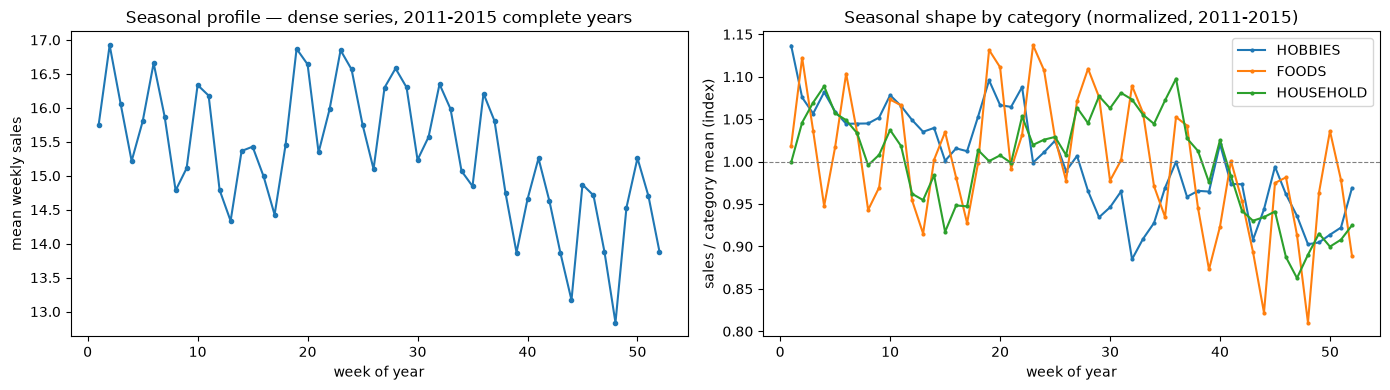

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# global, full years only (e.i. 2011-2016)
g = seasonal_clean[seasonal_clean["woy"] <= 52]
ax[0].plot(g["woy"], g["mean_sales"], marker="o", ms=3)
ax[0].set_xlabel("week of year")
ax[0].set_ylabel("mean weekly sales")
ax[0].set_title("Seasonal profile — dense series, 2011-2015 complete years")

# by category, normalised
for cat in seasonal_cat_clean["cat_id"].unique():
    sub = seasonal_cat_clean[
        (seasonal_cat_clean["cat_id"] == cat) & (seasonal_cat_clean["woy"] <= 52)
    ].copy()
    sub["norm"] = sub["mean_sales"] / sub["mean_sales"].mean()
    ax[1].plot(sub["woy"], sub["norm"], marker="o", ms=2, label=cat)
ax[1].axhline(1.0, color="gray", ls="--", lw=0.8)
ax[1].set_xlabel("week of year")
ax[1].set_ylabel("sales / category mean (index)")
ax[1].set_title("Seasonal shape by category (normalized, 2011-2015)")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Map woy -> month
(dense_full.withColumn("woy", F.col("wm_yr_wk") % 100)
    .groupBy("woy").agg(F.min("month").alias("month"))
    .orderBy("woy").show(55))

+---+-----+
|woy|month|
+---+-----+
|  1|    1|
|  2|    2|
|  3|    2|
|  4|    2|
|  5|    2|
|  6|    3|
|  7|    3|
|  8|    3|
|  9|    3|
| 10|    3|
| 11|    4|
| 12|    4|
| 13|    4|
| 14|    4|
| 15|    5|
| 16|    5|
| 17|    5|
| 18|    5|
| 19|    6|
| 20|    6|
| 21|    6|
| 22|    6|
| 23|    6|
| 24|    7|
| 25|    7|
| 26|    7|
| 27|    7|
| 28|    8|
| 29|    8|
| 30|    8|
| 31|    8|
| 32|    8|
| 33|    9|
| 34|    9|
| 35|    9|
| 36|    9|
| 37|   10|
| 38|   10|
| 39|   10|
| 40|   10|
| 41|   11|
| 42|   11|
| 43|   11|
| 44|   11|
| 45|   11|
| 46|   12|
| 47|   12|
| 48|    1|
| 49|    1|
| 50|    1|
| 51|    1|
| 52|    1|
| 53|    1|
+---+-----+



## EDA-4 (seasonality) -- apparent profile is a truncation artifact

- **Walmart's fiscal year starts in February** (woy 1 = Feb, woy 48-52 = Jan).
  Reading the profile against civil months was misleading until this mapping
  was checked.
- Corrected reading: **spring/early-summer plateau (Apr-Jun, woy ~11-23)**,
  decline into a **Dec-Jan trough (woy ~46-52)**. The January trough is the
  normal post-holiday dip.
- December is lower than naive "retail = Christmas" intuition would suggest.
  Likely because the signal is **unit sales (not revenue), the pool is
  FOODS-dominated (53%), and Walmart closes Dec 25** — grocery volume peaks at
  Thanksgiving rather than Christmas. Left as a hypothesis, not asserted.
- Regular high/low zigzag = **monthly SNAP effect** (benefits paid early in the
  month) — to be quantified next.
- **Feature decision unchanged:** seasonal deviation stays per-series YoY (N-1),
  robust to the global profile shape by construction.

## EDA-5 Snap effect

In [23]:
# Snap effect: average sales per number of snap days in week
snap_effect = (
    dense.groupBy("snap_days")
    .agg(
        F.mean("sales").alias("mean_sales"),
        F.count("*").alias("n"),
    )
    .orderBy("snap_days")
    .toPandas()
)
print(snap_effect)

# snap supposedly only on food category, check by category
snap_by_cat = (
    dense.groupBy("cat_id", "snap_days")
    .agg(F.mean("sales").alias("mean_sales"))
    .orderBy("cat_id", "snap_days")
    .toPandas()
)

   snap_days  mean_sales        n
0          0   14.578213  1336072
1          1   14.938091   280557
2          2   14.956396   320935
3          3   15.619952   219501
4          4   15.590723   490323
5          5   15.733464   477218
6          6   16.495998   117432
7          7   16.741139   180680


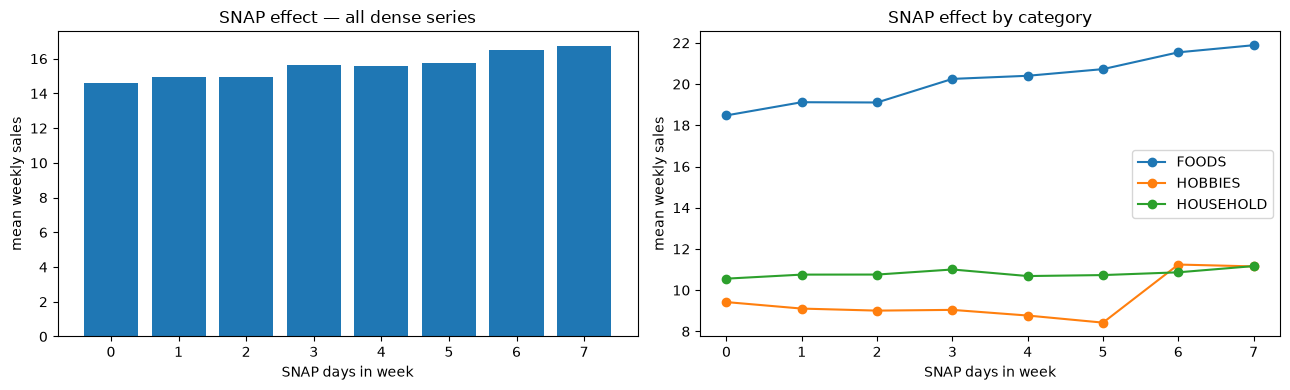

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(snap_effect["snap_days"], snap_effect["mean_sales"])
ax[0].set_xlabel("SNAP days in week")
ax[0].set_ylabel("mean weekly sales")
ax[0].set_title("SNAP effect — all dense series")

for cat in snap_by_cat["cat_id"].unique():
    sub = snap_by_cat[snap_by_cat["cat_id"] == cat]
    ax[1].plot(sub["snap_days"], sub["mean_sales"], marker="o", label=cat)
ax[1].set_xlabel("SNAP days in week")
ax[1].set_ylabel("mean weekly sales")
ax[1].set_title("SNAP effect by category")
ax[1].legend()

plt.tight_layout()
plt.show()

## EDA-5 (SNAP) -- category-conditional effect

- Global SNAP effect is modest (+15% from 0 to 7 SNAP days) but **diluted**:
  SNAP only applies to food-eligible purchases, and FOODS is 53% of the pool.
- By category the picture is clean: **FOODS rises monotonically (~18.5 -> 22,
  +19%)** with SNAP days; **HOBBIES and HOUSEHOLD are flat** (not SNAP-eligible).
  The HOBBIES uptick at 6-7 SNAP days is small-sample noise.
- **Feature decision:** keep `snap_days` as a feature and include `cat_id` in the
  feature set, letting the models learn the SNAP×category interaction rather than
  hand-crafting a `snap_days×FOODS` cross. Same "give ingredients, don't
  over-specify" logic as the P1 ablation finding.

## EDA-6 (Event)

In [29]:
# Retrieve event types by week
_, calendar, _ = load_raw(spark)
cal_events = (
    calendar
    .select("wm_yr_wk", "event_type_1")
    .filter(F.col("event_type_1").isNotNull())
    .dropDuplicates(["wm_yr_wk", "event_type_1"])
)

# join with dense series grid
dense_ev = dense.join(cal_events, on="wm_yr_wk", how="left")

# Baseline : weeks with no events
baseline = dense.filter(F.col("n_events") == 0) \
                .agg(F.mean("sales").alias("m")).collect()[0]["m"]
print(f"baseline (no-event weeks): {baseline:.2f}")

lift_by_type = (
    dense_ev.filter(F.col("event_type_1").isNotNull())
    .groupBy("event_type_1")
    .agg(
        F.mean("sales").alias("mean_sales"),
        F.count("*").alias("n"),
    )
    .withColumn("lift_pct", (F.col("mean_sales") / F.lit(baseline) - 1) * 100)
    .orderBy("event_type_1")
    .toPandas()
)
print(lift_by_type)

baseline (no-event weeks): 15.23


  event_type_1  mean_sales       n  lift_pct
0     Cultural   15.217728  457773 -0.075507
1     National   14.712469  634652 -3.393199
2    Religious   15.213543  617028 -0.102987
3     Sporting   16.206753  191368  6.418752


## EDA-6 (events) -- only Sporting events matter

- Weekly sales lift vs no-event baseline (15.23): **Cultural -0.1%, Religious
  -0.1%, National -3.4%, Sporting +6.4%.** Three of four event types have no
  measurable effect at the weekly grain; National is mildly negative (holiday
  closures, incl. Dec 25).
- Only **Sporting (Super Bowl) shows a real lift (+6.4%)** — and even that is a
  lower bound, since the weekly grain dilutes a 1-day spike across 7 days.
- **Feature decision:** drop the raw `n_events` count (it aggregates mostly
  null-effect events, drowning the one type that matters) and replace it with a
  single **`is_sporting_week` binary flag.** A data-justified subtractive choice.
- Sporting lift is confounded with early-February seasonality, but that's
  acceptable for a context feature (the goal is to set the expected level).